# 11. 넷플릭스 데이터 시각화 심화 분석

기존 `data/netflix_titles.csv`를 사용해 `pandas` 전처리와
`matplotlib` / `seaborn` 시각화를 단계별로 연습합니다.

**학습 목표**
1. 결측치 확인과 처리
2. 문자열 컬럼 분리(`str.split`, `explode`)로 장르/국가 다중값 다루기
3. `groupby` / `value_counts`로 집계
4. 막대·선·히트맵 등 다양한 그래프 그리기

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (Windows: 맑은 고딕) + 마이너스 기호 깨짐 방지
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font="Malgun Gothic")

# 데이터 로드
df = pd.read_csv("data/netflix_titles.csv")
print(df.shape)
df.head(3)

(8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


In [2]:
# 결측치 비율 확인 (많은 순으로 정렬)
missing = df.isna().mean().mul(100).round(1).sort_values(ascending=False)
missing[missing > 0]

director      29.9
cast           9.4
country        9.4
date_added     0.1
dtype: float64

In [3]:
# 분석에 필요한 전처리
# 1) date_added를 날짜형으로 변환하고 추가 연도 컬럼 생성
df["date_added"] = pd.to_datetime(df["date_added"].str.strip(), errors="coerce")
df["year_added"] = df["date_added"].dt.year

# 2) country 결측은 'Unknown'으로 대체
df["country"] = df["country"].fillna("Unknown")

df[["title", "date_added", "year_added", "type"]].head()

,title,date_added,year_added,type
0,Dick Johnson Is Dead,2021-09-25,2021.0,Movie
1,Blood & Water,2021-09-24,2021.0,TV Show
2,Ganglands,2021-09-24,2021.0,TV Show
3,Jailbirds New Orleans,2021-09-24,2021.0,TV Show
4,Kota Factory,2021-09-24,2021.0,TV Show


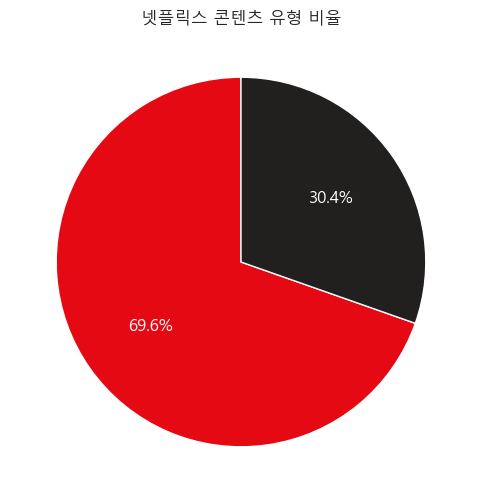

In [4]:
# [그래프 1] 콘텐츠 유형(Movie/TV Show) 비율
type_counts = df["type"].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(type_counts, labels=type_counts.index, autopct="%1.1f%%",
       startangle=90, colors=["#E50914", "#221F1F"], textprops={"color": "white"})
ax.set_title("넷플릭스 콘텐츠 유형 비율")
plt.show()

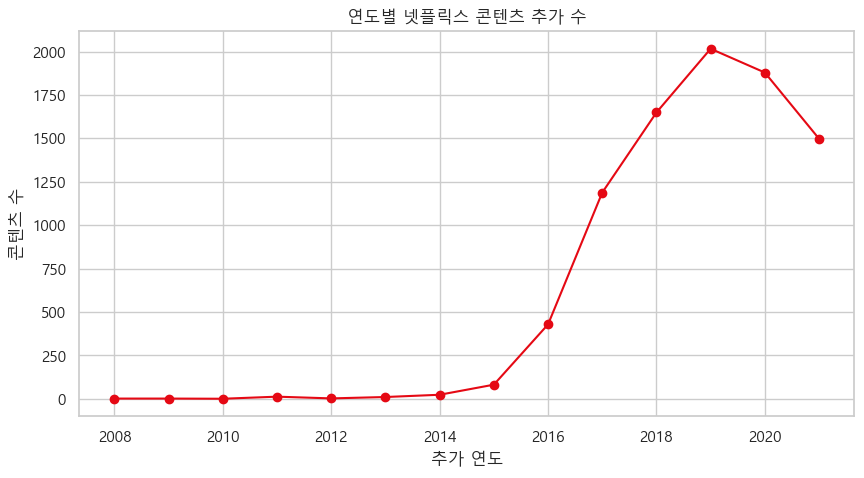

In [5]:
# [그래프 2] 연도별 추가된 콘텐츠 수 추이 (선그래프)
yearly = df.dropna(subset=["year_added"]).groupby("year_added").size()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(yearly.index, yearly.values, marker="o", color="#E50914")
ax.set_title("연도별 넷플릭스 콘텐츠 추가 수")
ax.set_xlabel("추가 연도")
ax.set_ylabel("콘텐츠 수")
plt.show()

C:\Users\vega2\AppData\Local\Temp\ipykernel_31128\3703701599.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, ax=ax, palette="Reds_r")


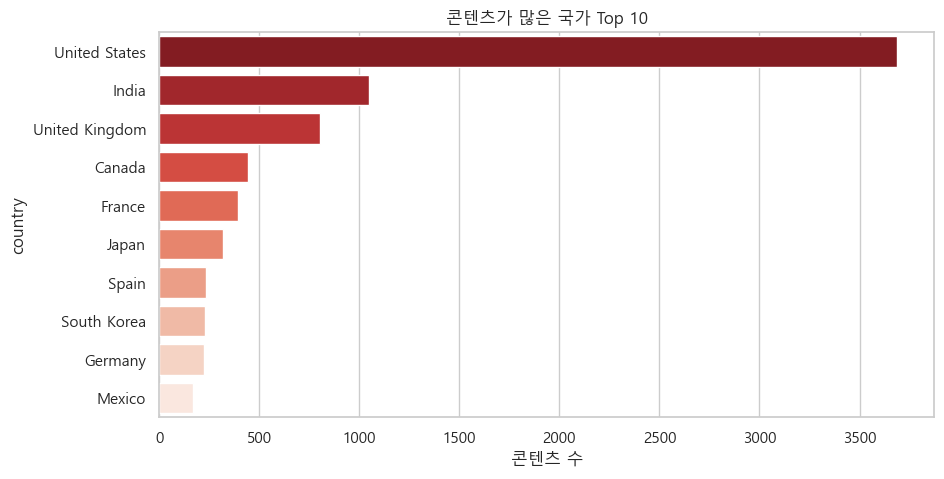

In [6]:
# [그래프 3] 콘텐츠가 많은 국가 Top 10
# country 컬럼은 'United States, India' 처럼 여러 국가가 콤마로 묶여있다
# → split 후 explode로 한 행에 한 국가씩 펼친다
country_series = (
    df["country"]
    .str.split(", ")
    .explode()
    .str.strip()
)
top_countries = country_series[country_series != "Unknown"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, ax=ax, palette="Reds_r")
ax.set_title("콘텐츠가 많은 국가 Top 10")
ax.set_xlabel("콘텐츠 수")
plt.show()

C:\Users\vega2\AppData\Local\Temp\ipykernel_31128\2756863689.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.values, y=genre_counts.index, ax=ax, palette="viridis")


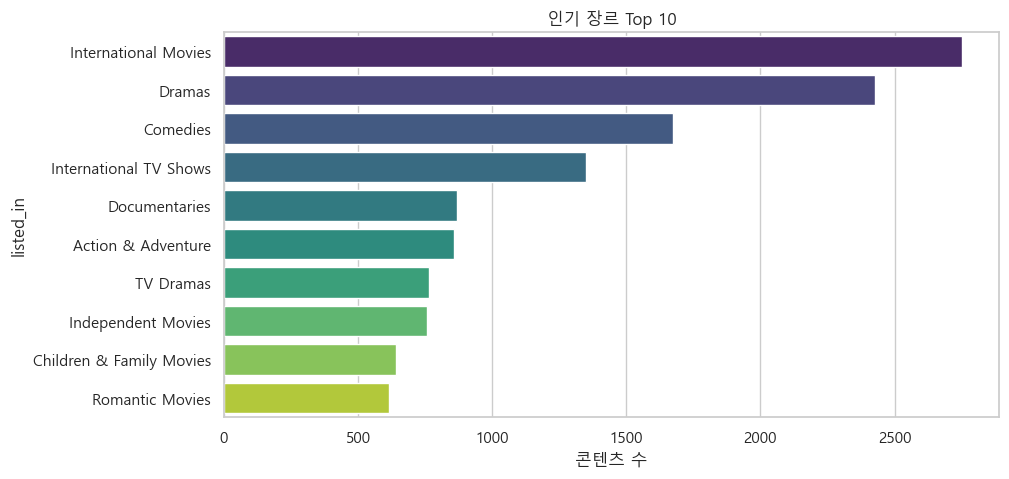

In [7]:
# [그래프 4] 인기 장르 Top 10 (listed_in 컬럼도 다중값)
genre_counts = (
    df["listed_in"]
    .str.split(", ")
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=genre_counts.values, y=genre_counts.index, ax=ax, palette="viridis")
ax.set_title("인기 장르 Top 10")
ax.set_xlabel("콘텐츠 수")
plt.show()

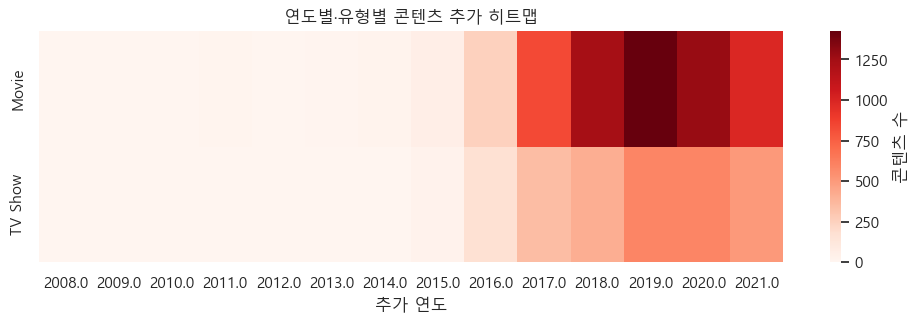

In [8]:
# [그래프 5] 연도 x 유형 히트맵 — 언제 어떤 유형이 많이 추가됐나
pivot = (
    df.dropna(subset=["year_added"])
      .pivot_table(index="type", columns="year_added", values="show_id",
                   aggfunc="count", fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 3))
sns.heatmap(pivot, cmap="Reds", annot=False, ax=ax, cbar_kws={"label": "콘텐츠 수"})
ax.set_title("연도별·유형별 콘텐츠 추가 히트맵")
ax.set_xlabel("추가 연도")
ax.set_ylabel("")
plt.show()

## 정리
- `str.split(...).explode()` 패턴으로 콤마로 묶인 다중값을 손쉽게 집계했습니다.
- `pivot_table` + `heatmap`으로 두 축의 관계를 한눈에 표현했습니다.

**연습 과제**
1. `rating`(관람등급)별 콘텐츠 수를 막대그래프로 그려보세요.
2. 영화(Movie)의 `duration`(예: '90 min')에서 숫자만 추출해 상영시간 분포를 그려보세요.